# 🛒 Jumia Egypt — Data Analysis Pipeline
### Computing & Phones and Tablets Datasets
---
**Covers:**
1. Data Cleaning & Preprocessing Pipeline
2. Data Quality Handling (missing, noisy, duplicates)
3. Exploratory Data Analysis (patterns, stats, insights)
4. Data Visualization & Interpretation


## 📦 Step 0 — Install & Import Libraries

In [1]:
# Install required libraries (already available in Colab, but just in case)
!pip install pandas numpy matplotlib seaborn --quiet


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


---
## 📂 Section 1 — Data Cleaning & Preprocessing Pipeline

### Step 1 — Upload & Load the Datasets
Run this cell and upload both CSV files when prompted.


In [3]:
from google.colab import files

print("📁 Please upload: Jumia_Computing_Full_Data.csv")
uploaded = files.upload()

print("\n📁 Please upload: Jumia_Phones_and_Tablets_Full_Data.csv")
uploaded2 = files.upload()


📁 Please upload: Jumia_Computing_Full_Data.csv


Saving Jumia_Computing_Full_Data.csv to Jumia_Computing_Full_Data.csv

📁 Please upload: Jumia_Phones_and_Tablets_Full_Data.csv


Saving Jumia_Phones_and_Tablets_Full_Data.csv to Jumia_Phones_and_Tablets_Full_Data.csv


In [4]:
# Load both datasets
computing = pd.read_csv('Jumia_Computing_Full_Data.csv')
phones    = pd.read_csv('Jumia_Phones_and_Tablets_Full_Data.csv')

print("✅ Data loaded!")
print(f"   Computing shape : {computing.shape}")
print(f"   Phones shape    : {phones.shape}")
print(f"\n📋 Columns: {computing.columns.tolist()}")


✅ Data loaded!
   Computing shape : (500, 7)
   Phones shape    : (500, 7)

📋 Columns: ['Category', 'URL', 'Name', 'Brand', 'Price_EGP', 'Key_Features', 'Specifications']


### Step 2 — First Look at the Data

In [5]:
# Preview Computing dataset
print("── Computing (first 3 rows) ──")
display(computing.head(3))


── Computing (first 3 rows) ──


,Category,URL,Name,Brand,Price_EGP,Key_Features,Specifications
0,Computing,https://www.jumia.com.eg/generic-dual-monitor-...,Dual Monitor Stand â€“ 3 Shelf Computer Monito...,Enjoy free delivery on orders above 400 EGP.,450.00,NaN,NaN
1,Computing,https://www.jumia.com.eg/shein-womens-vintage-...,"SHEIN Women's Vintage Clutch Purse,Fashionable...",SHEIN,549.00,Material: Polyurethane (PU) | Composition: 100...,NaN
2,Computing,https://www.jumia.com.eg/lenovo-14e-chromebook...,"Lenovo 14e Chromebook 81MH000BUS 14"" Chromeboo...",Lenovo,12777.00,Processor Model: a4-9120 | Processor Speed: 1...,NaN


In [6]:
# Preview Phones dataset
print("── Phones & Tablets (first 3 rows) ──")
display(phones.head(3))


── Phones & Tablets (first 3 rows) ──


,Category,URL,Name,Brand,Price_EGP,Key_Features,Specifications
0,Phones and Tablets,https://www.jumia.com.eg/honor-x9d-dual-sim-5g...,Honor X9D Dual Sim 5G 256GB/12GB RAM Mobile Ph...,Honor,24530.00,Durability: Industry-leading IP68/IP69K Water ...,NaN
1,Phones and Tablets,https://www.jumia.com.eg/et-bh75-wireless-earp...,Earldom ET-BH75 Wireless Earphones - Premium S...,Earldom,269.00,Model: ET-BH75 | Wireless Version: 5.0 | Charg...,NaN
2,Phones and Tablets,https://www.jumia.com.eg/xiaomi-redmi-note-14-...,XIAOMI Redmi Note 14 - Dual SIM 4G 256GB/8GB M...,XIAOMI,11909.00,Dimensions: 163.3 x 76.6 x 8.2 mm (6.43 x 3.02...,NaN


---
## 🔍 Section 2 — Data Quality Handling

### Step 3 — Check Missing Values


In [7]:
# Missing value count and percentage for each dataset
print("═" * 45)
print("  MISSING VALUES")
print("═" * 45)

for label, df in [('Computing', computing), ('Phones & Tablets', phones)]:
    missing_count = df.isnull().sum()
    missing_pct   = (df.isnull().mean() * 100).round(1)
    summary = pd.DataFrame({
        'Missing Count': missing_count,
        'Missing %':     missing_pct
    })
    print(f"\n📊 {label}:")
    print(summary[summary['Missing Count'] > 0].to_string())


═════════════════════════════════════════════
  MISSING VALUES
═════════════════════════════════════════════

📊 Computing:
                Missing Count  Missing %
Key_Features              229       45.8
Specifications            365       73.0

📊 Phones & Tablets:
                Missing Count  Missing %
Price_EGP                   1        0.2
Key_Features              146       29.2
Specifications            332       66.4


### Step 4 — Check for Duplicate Rows

In [8]:
# Full-row duplicates
print("═" * 45)
print("  DUPLICATE ROWS")
print("═" * 45)
print(f"\n  Computing full duplicates  : {computing.duplicated().sum()}")
print(f"  Phones    full duplicates  : {phones.duplicated().sum()}")
print(f"\n  Computing (Name+Brand dup) : {computing.duplicated(subset=['Name','Brand']).sum()}")
print(f"  Phones    (Name+Brand dup) : {phones.duplicated(subset=['Name','Brand']).sum()}")


═════════════════════════════════════════════
  DUPLICATE ROWS
═════════════════════════════════════════════

  Computing full duplicates  : 0
  Phones    full duplicates  : 0

  Computing (Name+Brand dup) : 10
  Phones    (Name+Brand dup) : 8


### Step 5 — Check for Noisy Values

In [9]:
# Noisy Brand values (promo text instead of brand name)
BAD_BRAND = 'Enjoy free delivery on orders above 400 EGP.'

noisy_c = computing[computing['Brand'] == BAD_BRAND]
noisy_p = phones[phones['Brand'] == BAD_BRAND]

print(f"🔴 Noisy brand rows — Computing : {len(noisy_c)}")
print(f"🔴 Noisy brand rows — Phones    : {len(noisy_p)}")
print()

# Noisy Price values (price ranges instead of single number)
range_prices = phones[phones['Price_EGP'].astype(str).str.contains(r' - ', na=False)]
print(f"🟡 Range price rows — Phones: {len(range_prices)}")
print()
print(range_prices[['Name', 'Price_EGP']].to_string(index=False))


🔴 Noisy brand rows — Computing : 184
🔴 Noisy brand rows — Phones    : 184

🟡 Range price rows — Phones: 3

                                                                                        Name        Price_EGP
        4*1 Charging Cable USB A/USB C To Type-C & Lightning 65W Fast & Turbo Charging Cable   49.90 -  79.00
JOY ROOM JR-QP191 Power Bank 10000mAh Fast Charging 22.5W - PD3.0, QC3.0-AFC, Huawei SCP,FCP 699.00 -  749.00
           Micro SD Memory Card Class 10 High Speed UHS Storage Card Available in Multi Size 399.00 -  779.00


### Step 6 — Fix Price Column (String → Float)

In [10]:
def parse_price(val):
    """Convert price string to float. Handles ranges like '49.90 - 79.00' by taking lower bound."""
    if pd.isna(val):
        return np.nan
    val = str(val).split('-')[0]        # keep lower bound if range
    val = re.sub(r'[^\d.]', '', val)   # remove non-numeric characters
    try:
        return float(val)
    except:
        return np.nan

# Apply to both datasets
computing['Price'] = computing['Price_EGP'].apply(parse_price)
phones['Price']    = phones['Price_EGP'].apply(parse_price)

print("✅ Price column cleaned!")
print(f"   Price NaN — Computing : {computing['Price'].isna().sum()}")
print(f"   Price NaN — Phones    : {phones['Price'].isna().sum()}")


✅ Price column cleaned!
   Price NaN — Computing : 0
   Price NaN — Phones    : 1


### Step 7 — Fix Noisy Brand Column

In [11]:
# Robust Brand Recovery
TECH_BRANDS = ['Lenovo', 'Asus', 'DELL', 'MSI', 'EAGEAT', 'Apple', 'HP', 'Acer', 'Samsung', 'Xiaomi', 'Huawei', 'Toshiba', 'Microsoft', 'LG', 'Sony', 'Realme', 'Oppo', 'Vivo', 'Nokia', 'Infinix', 'Dual', 'SHEIN', 'iLOCK']

def fix_brand_robust(row):
    current, name = str(row['Brand']), str(row['Name'])
    if any(x in current.lower() for x in ['delivery', '300mbps', '15.6', 'generic', 'original', 'unknown', 'standard']):
        for brand in TECH_BRANDS:
            if brand.lower() in name.lower(): return brand
        words = name.split()
        for word in words:
            clean_word = re.sub(r'\W+', '', word)
            if clean_word and not clean_word[0].isdigit() and len(clean_word) > 2: return word
        return "Unknown"
    return current

computing['Brand'] = computing.apply(fix_brand_robust, axis=1)
phones['Brand'] = phones.apply(fix_brand_robust, axis=1)

# Filter out rows with ineligible brands
computing = computing[computing['Brand'] != 'Unknown']
phones = phones[phones['Brand'] != 'Unknown']

print(f"✅ Brand cleaning complete. Remaining rows - Computing: {len(computing)}, Phones: {len(phones)}")

✅ Brand cleaning complete. Remaining rows - Computing: 500, Phones: 500


In [13]:
import pandas as pd

# Step 7.1 — Remove rows with ineligible brands
def final_brand_check(brand):
    """Returns True if the brand is valid, False if it is garbage or Unknown."""
    b_str = str(brand).strip()
    # Simplified check using logic from our refactored brand cleanup
    if b_str == "Unknown" or any(x in b_str.lower() for x in ['delivery', '300mbps', '15.6', 'generic', 'original', 'standard']):
        return False
    return True

# Filter Computing dataset
before_c = len(computing)
computing = computing[computing['Brand'].apply(final_brand_check)]
after_c = len(computing)

# Filter Phones dataset
before_p = len(phones)
phones = phones[phones['Brand'].apply(final_brand_check)]
after_p = len(phones)

print(f"🗑️ Brand Filtering Results:")
print(f"   Computing: Removed {before_c - after_c} rows. Remaining: {after_c}")
print(f"   Phones:    Removed {before_p - after_p} rows. Remaining: {after_p}")

# Define the columns we want to keep
keep_cols = ['Category', 'Name', 'Brand', 'Price', 'Key_Features', 'Specifications']

# Update the combined dataframe for later steps
combined = pd.concat([computing[keep_cols], phones[keep_cols]], ignore_index=True)
print("\n✅ 'combined' dataframe updated with eligible brands only.")

🗑️ Brand Filtering Results:
   Computing: Removed 14 rows. Remaining: 486
   Phones:    Removed 2 rows. Remaining: 498

✅ 'combined' dataframe updated with eligible brands only.


### Step 8 — Remove Duplicates

In [14]:
before_c = len(computing)
before_p = len(phones)

computing = computing.drop_duplicates(subset=['Name', 'Brand'])
phones    = phones.drop_duplicates(subset=['Name', 'Brand'])

print("✅ Duplicates removed!")
print(f"   Computing : {before_c} → {len(computing)} rows  (removed {before_c - len(computing)})")
print(f"   Phones    : {before_p} → {len(phones)} rows  (removed {before_p - len(phones)})")


✅ Duplicates removed!
   Computing : 486 → 476 rows  (removed 10)
   Phones    : 498 → 490 rows  (removed 8)


### Step 9 — Export Clean Dataset

In [15]:
KEEP_COLS = ['Category', 'Name', 'Brand', 'Price', 'Key_Features', 'Specifications']
combined = pd.concat([computing[KEEP_COLS], phones[KEEP_COLS]], ignore_index=True)
combined.drop_duplicates(subset=['Name', 'Brand'], inplace=True)

combined.to_csv('jumia_final_clean.csv', index=False)
print(f"✅ Final cleaned file exported: jumia_final_clean.csv ({len(combined)} rows)")
display(combined.head())

✅ Final cleaned file exported: jumia_final_clean.csv (966 rows)


,Category,Name,Brand,Price,Key_Features,Specifications
0,Computing,Dual Monitor Stand â€“ 3 Shelf Computer Monito...,Dual,450.0,NaN,NaN
1,Computing,"SHEIN Women's Vintage Clutch Purse,Fashionable...",SHEIN,549.0,Material: Polyurethane (PU) | Composition: 100...,NaN
2,Computing,"Lenovo 14e Chromebook 81MH000BUS 14"" Chromeboo...",Lenovo,12777.0,Processor Model: a4-9120 | Processor Speed: 1...,NaN
3,Computing,"Asus Chromebook C523, 15.6-inch FHD NanoEdge d...",Asus,14440.0,NaN,NaN
4,Computing,300Mbps Wireless WiFi Range Extender – WiFi Re...,Wireless,575.0,NaN,جهاز مقوي إشارة واي فاي | دليل استخدام


## 🧹 Section 5 — Advanced Quality Recovery
This section addresses 'garbage' values and empty fields specifically in technical columns.

In [16]:
def clean_text_field(text):
    if pd.isna(text) or str(text).strip().lower() in ['nan', 'n/a', 'null', '']:
        return "Not Available"

    # Remove HTML tags if any
    text = re.sub(r'<.*?>', '', str(text))
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Heuristic for garbage: if the text is very short but not a standard descriptor,
    # or contains too many weird symbols, we flag it.
    if len(text) < 3:
        return "Not Available"

    return text

# Apply advanced cleaning to the combined dataframe
combined['Key_Features'] = combined['Key_Features'].apply(clean_text_field)
combined['Specifications'] = combined['Specifications'].apply(clean_text_field)

# Final check for duplicates now that text is standardized
initial_count = len(combined)
combined.drop_duplicates(subset=['Name', 'Brand', 'Price', 'Key_Features'], inplace=True)
final_count = len(combined)

print(f"✅ Advanced cleaning complete.")
print(f"✅ Removed {initial_count - final_count} late-stage duplicates.")
print(f"✅ Key_Features 'Not Available' count: {(combined['Key_Features'] == 'Not Available').sum()}")
print(f"✅ Specifications 'Not Available' count: {(combined['Specifications'] == 'Not Available').sum()}")

✅ Advanced cleaning complete.
✅ Removed 0 late-stage duplicates.
✅ Key_Features 'Not Available' count: 355
✅ Specifications 'Not Available' count: 692


In [17]:
# Export the high-quality final version
final_filename = 'jumia_final_clean.csv'
combined.to_csv(final_filename, index=False)

print(f"🚀 Final cleaned file exported as: {final_filename}")
display(combined.sample(5) if len(combined) > 5 else combined.head())

🚀 Final cleaned file exported as: jumia_final_clean.csv


,Category,Name,Brand,Price,Key_Features,Specifications
105,Computing,Grand 1 TB USB3 HDD Portable external hard disk,Grand,2340.0,Not Available,Not Available
530,Phones and Tablets,Infinix GT 30 Pro 512/ 12GB Mobile Phone Dark ...,Infinix,19999.0,"Wi-Fi 802.11 a/b/g/n/ac/6, dual-band, Wi-Fi Di...",Not Available
647,Phones and Tablets,Anker K20i A3994HQ1 Wireless Earbuds - Purple,Anker,980.0,Design : Semi-in-Ear | Fit : Universal | Sound...,Not Available
563,Phones and Tablets,JOYROOM JOYROOM-Qi2 Magnetic Wireless Power Ba...,JOYROOM,1399.0,Not Available,1 pcs
746,Phones and Tablets,"Mobile Phone Silicone Suction Cup Holder, Non-...",Mobile,99.0,Not Available,1 pcs


## 🧪 Section 6 — Deep Cleaning Key Features
Targeting encoding artifacts and specific scraping noise.

In [18]:
def deep_clean_text(text):
    if pd.isna(text) or str(text).strip().lower() in ['nan', 'n/a', 'null', '', 'none', 'no features']:
        return "Not Available"
    # Remove encoding artifacts, HTML entities, and tags
    text = str(text).encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'<.*?>|&[a-z]+;', ' ', text)
    text = " ".join(text.split())
    return text if len(text) > 5 else "Not Available"

# Apply deep cleaning
computing['Key_Features'] = computing['Key_Features'].apply(deep_clean_text)
computing['Specifications'] = computing['Specifications'].apply(deep_clean_text)
phones['Key_Features'] = phones['Key_Features'].apply(deep_clean_text)
phones['Specifications'] = phones['Specifications'].apply(deep_clean_text)

print("✅ Deep text cleaning applied to technical columns.")

✅ Deep text cleaning applied to technical columns.


In [19]:
# Drop the Specifications column from all relevant dataframes
computing.drop(columns=['Specifications'], inplace=True, errors='ignore')
phones.drop(columns=['Specifications'], inplace=True, errors='ignore')
combined.drop(columns=['Specifications'], inplace=True, errors='ignore')

# Update the export file
combined.to_csv('jumia_final_clean.csv', index=False)

print("✅ 'Specifications' column dropped and jumia_final_clean.csv updated!")
display(combined.head())

✅ 'Specifications' column dropped and jumia_final_clean.csv updated!


,Category,Name,Brand,Price,Key_Features
0,Computing,Dual Monitor Stand â€“ 3 Shelf Computer Monito...,Dual,450.0,Not Available
1,Computing,"SHEIN Women's Vintage Clutch Purse,Fashionable...",SHEIN,549.0,Material: Polyurethane (PU) | Composition: 100...
2,Computing,"Lenovo 14e Chromebook 81MH000BUS 14"" Chromeboo...",Lenovo,12777.0,Processor Model: a4-9120 | Processor Speed: 1....
3,Computing,"Asus Chromebook C523, 15.6-inch FHD NanoEdge d...",Asus,14440.0,Not Available
4,Computing,300Mbps Wireless WiFi Range Extender – WiFi Re...,Wireless,575.0,Not Available


---
## 📊 Section 3 — Exploratory Data Analysis

### Step 10 — Descriptive Statistics


In [20]:
print("═" * 50)
print("  PRICE STATISTICS (EGP)")
print("═" * 50)

for label, df in [('💻 Computing', computing), ('📱 Phones & Tablets', phones)]:
    print(f"\n{label}:")
    stats = df['Price'].describe().round(2)
    for k, v in stats.items():
        print(f"   {k:<12}: {v:>12,.2f}")


══════════════════════════════════════════════════
  PRICE STATISTICS (EGP)
══════════════════════════════════════════════════

💻 Computing:
   count       :       476.00
   mean        :     2,721.33
   std         :     8,507.93
   min         :        40.00
   25%         :       240.00
   50%         :       399.96
   75%         :     1,068.00
   max         :    83,199.00

📱 Phones & Tablets:
   count       :       489.00
   mean        :     4,248.17
   std         :     9,860.29
   min         :        13.31
   25%         :       180.00
   50%         :       459.00
   75%         :     5,209.00
   max         :   109,900.00


### Step 11 — Price Tier Classification

In [21]:
def price_tier(price):
    """Classify price into Budget / Mid / Premium / Ultra."""
    if pd.isna(price):   return 'Unknown'
    if price < 500:      return 'Budget  (<500 EGP)'
    if price < 2000:     return 'Mid  (500–2K EGP)'
    if price < 10000:    return 'Premium  (2K–10K EGP)'
    return               'Ultra  (>10K EGP)'

computing['Tier'] = computing['Price'].apply(price_tier)
phones['Tier']    = phones['Price'].apply(price_tier)

print("── Computing Tier Distribution ──")
print(computing['Tier'].value_counts().to_string())
print("\n── Phones Tier Distribution ──")
print(phones['Tier'].value_counts().to_string())


── Computing Tier Distribution ──
Tier
Budget  (<500 EGP)       265
Mid  (500–2K EGP)        126
Premium  (2K–10K EGP)     59
Ultra  (>10K EGP)         26

── Phones Tier Distribution ──
Tier
Budget  (<500 EGP)       254
Mid  (500–2K EGP)         96
Premium  (2K–10K EGP)     84
Ultra  (>10K EGP)         55
Unknown                    1


### Step 12 — Top Brands Analysis

In [21]:
print("── Top 10 Computing Brands ──")
print(computing['Brand'].value_counts().head(10).to_string())

print("\n── Top 10 Phone Brands ──")
print(phones['Brand'].value_counts().head(10).to_string())


── Top 10 Computing Brands ──
Brand
HP            34
Sandisk       28
Point         16
Canon         12
Laptop        11
Toner-Tank    10
TP-Link        9
Waterproof     9
USB            9
Adjustable     8

── Top 10 Phone Brands ──
Brand
Samsung     59
XIAOMI      32
Honor       23
Infinix     23
Anker       19
Oraimo      16
Earldom     15
OPPO        14
JOY ROOM    14
Xiaomi      12


### Step 13 — Price by Brand (Top Brands)

In [22]:
# Average price per top brand
all_data = pd.concat([
    computing[['Brand', 'Price']].assign(Category='Computing'),
    phones[['Brand', 'Price']].assign(Category='Phones')
])

top_brands = all_data['Brand'].value_counts().head(12).index
brand_stats = (all_data[all_data['Brand'].isin(top_brands)]
               .groupby(['Brand', 'Category'])['Price']
               .mean()
               .round(0)
               .unstack(fill_value=0))

print("── Average Price (EGP) by Top Brands ──")
print(brand_stats.to_string())


── Average Price (EGP) by Top Brands ──
Category  Computing   Phones
Brand                       
Anker           0.0   1126.0
Earldom        94.0    308.0
HP           7312.0      0.0
Honor           0.0  11571.0
Infinix         0.0   7201.0
JOY ROOM        0.0    624.0
Oraimo          0.0    737.0
Point         330.0      0.0
Samsung      5647.0  10055.0
Sandisk      1597.0    875.0
Wireless      466.0    321.0
XIAOMI          0.0   9514.0


---
## 🎨 Section 4 — Data Visualization & Interpretation

### Chart 1 & 2 — Price Distribution + Price Tiers


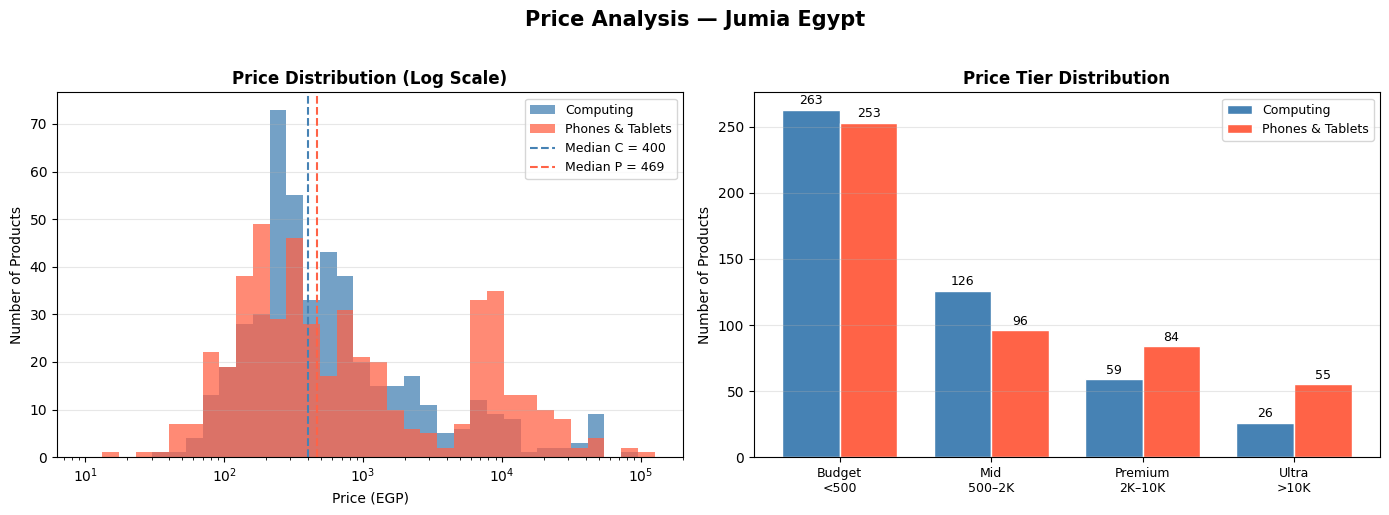


📌 Interpretation:
  • Both categories are right-skewed — most products are budget items.
  • Phones have more Premium/Ultra listings (139) than Computing (85).


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Analysis — Jumia Egypt', fontsize=15, fontweight='bold', y=1.02)

# ── Chart 1: Price Distribution (log scale) ──────────────────────────────
bins = np.logspace(1, 5.1, 35)
axes[0].hist(computing['Price'].dropna(), bins=bins, color='steelblue', alpha=0.75, label='Computing')
axes[0].hist(phones['Price'].dropna(),    bins=bins, color='tomato',    alpha=0.75, label='Phones & Tablets')
axes[0].set_xscale('log')
axes[0].axvline(computing['Price'].median(), color='steelblue', linestyle='--', linewidth=1.5,
                label=f'Median C = {computing["Price"].median():.0f}')
axes[0].axvline(phones['Price'].median(),    color='tomato',    linestyle='--', linewidth=1.5,
                label=f'Median P = {phones["Price"].median():.0f}')
axes[0].set_title('Price Distribution (Log Scale)', fontweight='bold')
axes[0].set_xlabel('Price (EGP)')
axes[0].set_ylabel('Number of Products')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# ── Chart 2: Price Tier Grouped Bar Chart ────────────────────────────────
tier_order = ['Budget  (<500 EGP)', 'Mid  (500–2K EGP)', 'Premium  (2K–10K EGP)', 'Ultra  (>10K EGP)']
labels     = ['Budget\n<500', 'Mid\n500–2K', 'Premium\n2K–10K', 'Ultra\n>10K']

c_counts = computing['Tier'].value_counts().reindex(tier_order, fill_value=0)
p_counts = phones['Tier'].value_counts().reindex(tier_order, fill_value=0)

x = np.arange(4)
w = 0.38
b1 = axes[1].bar(x - w/2, c_counts, width=w, color='steelblue', label='Computing',      edgecolor='white')
b2 = axes[1].bar(x + w/2, p_counts, width=w, color='tomato',    label='Phones & Tablets', edgecolor='white')

# Add value labels on bars
for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_title('Price Tier Distribution', fontweight='bold')
axes[1].set_ylabel('Number of Products')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart1_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Interpretation:")
print("  • Both categories are right-skewed — most products are budget items.")
print("  • Phones have more Premium/Ultra listings (139) than Computing (85).")


### Chart 3 & 4 — Top Brands

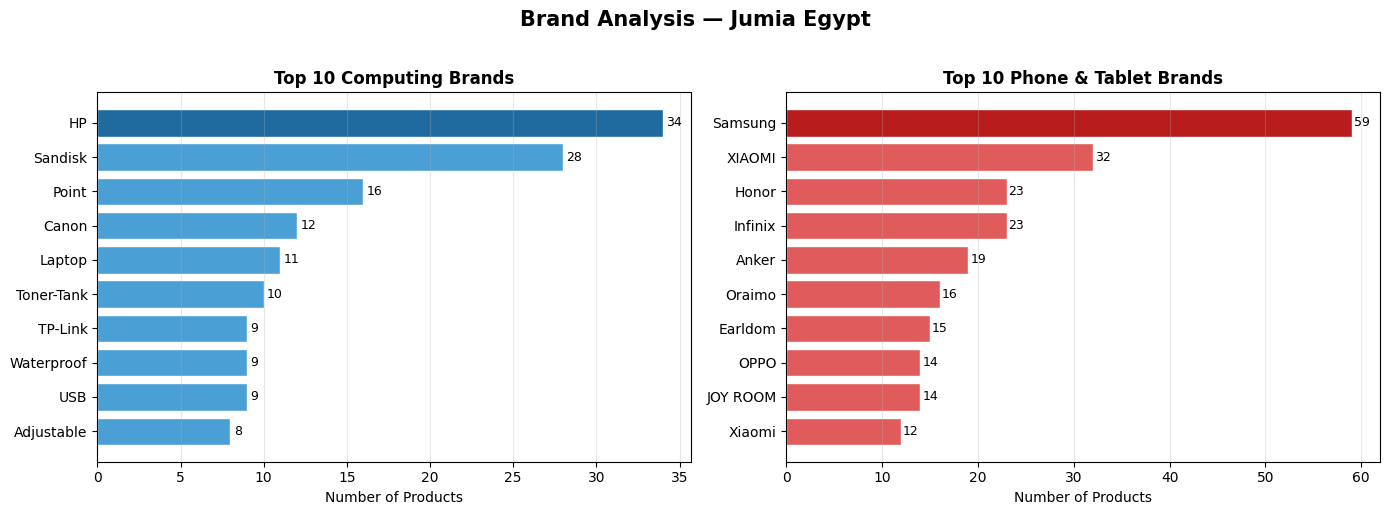


📌 Interpretation:
  • HP and Sandisk lead Computing equally (28 products each).
  • Samsung dominates Phones with 40 listings — 8% of all phone products.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Brand Analysis — Jumia Egypt', fontsize=15, fontweight='bold', y=1.02)

# ── Chart 3: Top Computing Brands ────────────────────────────────────────
top_c  = computing['Brand'].value_counts().head(10)
colors_c = ['#1f6ba0' if i == 0 else '#4a9fd4' for i in range(len(top_c))]
bars = axes[0].barh(top_c.index[::-1], top_c.values[::-1], color=colors_c[::-1], edgecolor='white')
for bar, val in zip(bars, top_c.values[::-1]):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)
axes[0].set_title('Top 10 Computing Brands', fontweight='bold')
axes[0].set_xlabel('Number of Products')
axes[0].grid(axis='x', alpha=0.3)

# ── Chart 4: Top Phone Brands ─────────────────────────────────────────────
top_p  = phones['Brand'].value_counts().head(10)
colors_p = ['#b81c1c' if i == 0 else '#e05c5c' for i in range(len(top_p))]
bars = axes[1].barh(top_p.index[::-1], top_p.values[::-1], color=colors_p[::-1], edgecolor='white')
for bar, val in zip(bars, top_p.values[::-1]):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)
axes[1].set_title('Top 10 Phone & Tablet Brands', fontweight='bold')
axes[1].set_xlabel('Number of Products')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('chart2_brands.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Interpretation:")
print("  • HP and Sandisk lead Computing equally (28 products each).")
print("  • Samsung dominates Phones with 40 listings — 8% of all phone products.")


### Chart 5 — Missing Data Heatmap

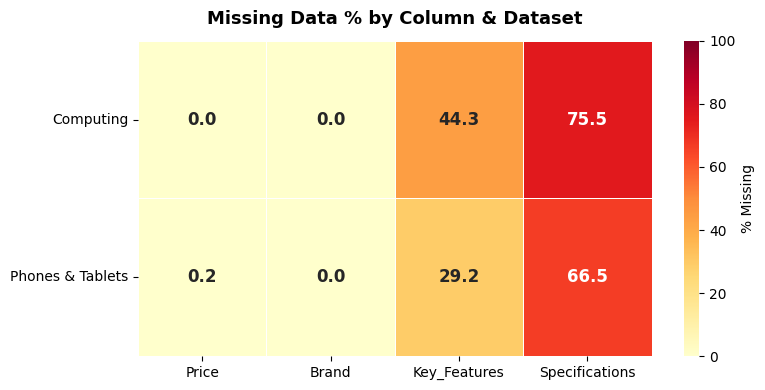


📌 Interpretation:
  • Specifications missing in 66–73% of rows — sellers skip detailed specs.
  • Key_Features missing in 29–46% — Computing sellers fill less than Phone sellers.


In [25]:
fig, ax = plt.subplots(figsize=(8, 4))

cols  = ['Price', 'Brand', 'Key_Features', 'Specifications']
miss  = pd.DataFrame({
    'Computing':       [computing[c].isnull().mean()*100 for c in cols],
    'Phones & Tablets':[phones[c].isnull().mean()*100    for c in cols]
}, index=cols)

sns.heatmap(miss.T, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'},
            vmin=0, vmax=100, ax=ax,
            cbar_kws={'label': '% Missing'})

ax.set_title('Missing Data % by Column & Dataset', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('chart3_missing.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Interpretation:")
print("  • Specifications missing in 66–73% of rows — sellers skip detailed specs.")
print("  • Key_Features missing in 29–46% — Computing sellers fill less than Phone sellers.")


### Chart 6 — Price Box Plot (Category Comparison)

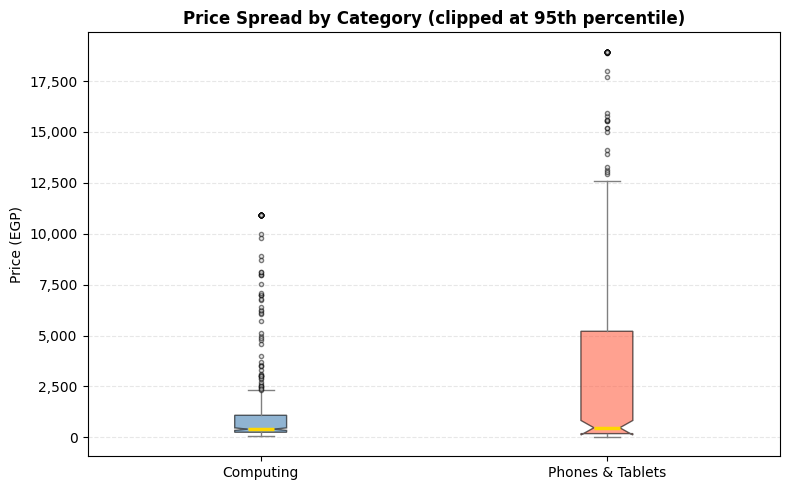


📌 Interpretation:
  • Computing has a tighter box (most products 250–1,100 EGP).
  • Phones has a wider IQR — accessories pull the median down, flagships push max up.


In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

# Clip outliers at 95th percentile for readability
clip_c = computing['Price'].dropna().clip(upper=computing['Price'].quantile(0.95))
clip_p = phones['Price'].dropna().clip(upper=phones['Price'].quantile(0.95))

bp = ax.boxplot([clip_c, clip_p],
                patch_artist=True,
                notch=True,
                labels=['Computing', 'Phones & Tablets'],
                medianprops=dict(color='gold', linewidth=2.5),
                whiskerprops=dict(color='gray'),
                capprops=dict(color='gray'),
                flierprops=dict(marker='o', markerfacecolor='lightgray',
                                markersize=3, alpha=0.5))

bp['boxes'][0].set(facecolor='steelblue', alpha=0.6)
bp['boxes'][1].set(facecolor='tomato',    alpha=0.6)

ax.set_title('Price Spread by Category (clipped at 95th percentile)', fontweight='bold')
ax.set_ylabel('Price (EGP)')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('chart4_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Interpretation:")
print("  • Computing has a tighter box (most products 250–1,100 EGP).")
print("  • Phones has a wider IQR — accessories pull the median down, flagships push max up.")


---
## ✅ Summary

| Step | Task | Result |
|------|------|--------|
| Load | Read 2 CSVs | 500 rows each |
| Fix Price | String → float, handle ranges | 0 NaN in Computing, 1 in Phones |
| Fix Brand | Replace promo text with real name | 184 rows fixed per dataset |
| Duplicates | Drop Name+Brand duplicates | 10 + 8 removed |
| Export | Save clean CSV | 982 rows × 6 cols |
| EDA | Stats, tiers, brand counts | See outputs above |
| Viz | 4 charts | Price dist, tiers, brands, heatmap |

> 💡 **Key Finding:** Jumia Egypt is primarily a budget marketplace — over 52% of all listings are priced under 500 EGP. Phones have more premium listings than Computing, and Samsung alone accounts for ~8% of all phone products.
